[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatsubaraSoda/Notebook/blob/main/notebooks/%E7%89%A9%E7%90%86%E5%AD%A6/%E7%94%B5%E7%A3%81%E5%AD%A6/%E5%85%89%E5%AD%A6/%E5%87%A0%E4%BD%95%E5%85%89%E5%AD%A6/parabolic-reflection.ipynb)

# 抛物线镜面反射

通过 Python 模拟平行光线射向抛物线镜面时，反射光线的行为。

取顶点在原点、开口朝左的抛物线，参数 $p = 8$，标准方程为

$$
y^2 = -2px
$$

## Step 1: 绘制坐标轴与抛物线

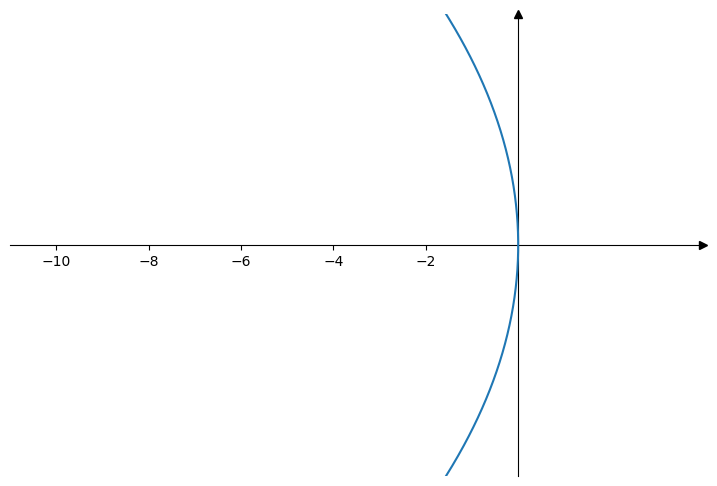

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 全局约定数值
p = 8.0                                     # 抛物线参数
beam_y = np.linspace(-4.5, 4.5, 7)          # 平行入射光束的高度
incident_direction = np.array([1.0, 0.0])   # 入射方向单位向量
intersection_points = np.empty((0, 2))      # 交点坐标
normals = np.empty((0, 2))                  # 交点处的法向量（归一化）
reflection_rays_unit = np.empty((0, 2))   # 反射光线单位方向

def set_scene():

    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.set_aspect('equal')
    ax.set_xticks([-10, -8, -6, -4, -2])
    ax.set_yticks([])
    ax.set_xlim([-11, 4])
    ax.set_ylim([-5, 5])

    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

def draw_parabola():

    y_vals = np.linspace(-5, 5, 500)
    x_vals = -y_vals**2 / (2 * p)

    ax.plot(x_vals, y_vals, zorder=5)

fig, ax = plt.subplots(figsize=(10, 6))
set_scene()
draw_parabola()

## Step 2: 绘制入射光线

从 $x$ 轴负方向射入七条彼此平行的光线，方向单位向量均为 $(1, 0)$。各光束在高度 $y \in [-4.5, 4.5]$ 上均匀取值，与抛物线 $y^2 = -2px$ 的交点存入 `intersection_points`，作为入射光的终点；起点取 `xlim` 左侧。

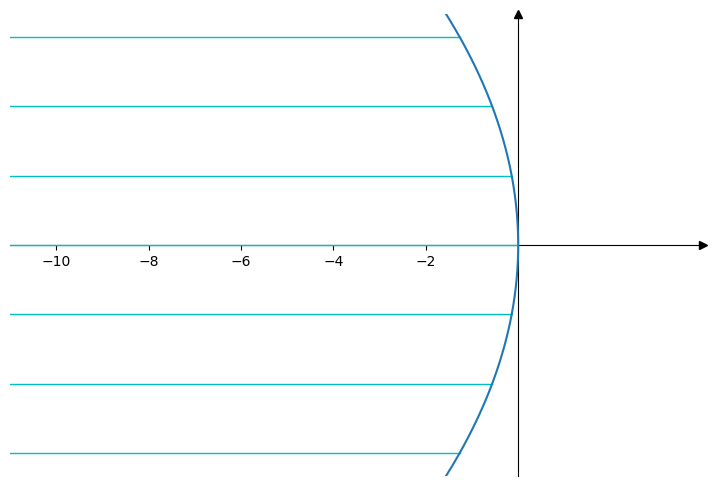

In [30]:
def _find_intersection_points():
    """
    水平入射光线 y = const 与抛物线 y^2 = -2px 的交点。
    解得 x = -y^2 / (2p)。
    """
    points = []
    for y in beam_y:
        x = -y**2 / (2 * p)
        points.append([x, y])
    return np.array(points, dtype=float)

intersection_points = _find_intersection_points()
# display(intersection_points)

def draw_incident_rays():
    x_start = ax.get_xlim()[0]
    for point in intersection_points:
        start = np.array([x_start, point[1]])
        ax.plot(
            [start[0], point[0]], [start[1], point[1]],
            color='c', linewidth=1, zorder=4,
        )

fig, ax = plt.subplots(figsize=(10, 6))
set_scene()
draw_parabola()
draw_incident_rays()

## Step 3: 绘制法向量

在交点处对隐式曲线 $y^2 + 2px = 0$ 求梯度得到法向量，并检验 $\mathbf{n}\cdot\mathbf{i} < 0$（法向与入射方向相向）；若不满足则取反。从各交点出发绘制单位法向量。

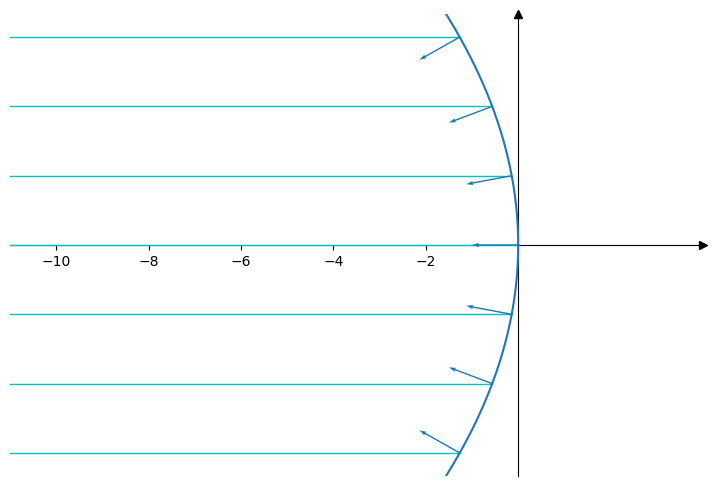

In [31]:
def _find_normals():
    import sympy as sp

    x, y = sp.symbols('x y', real=True)
    eq_parabola = y**2 + 2 * p * x
    gradient = [eq_parabola.diff(x), eq_parabola.diff(y)]

    normals = []
    for intersection_point in intersection_points:
        normal = np.array([
            float(gradient[0].subs({x: intersection_point[0], y: intersection_point[1]})),
            float(gradient[1].subs({x: intersection_point[0], y: intersection_point[1]})),
        ], dtype=float)
        normal = normal / np.linalg.norm(normal)

        if np.dot(normal, incident_direction) > 0:    # 二者同向
            normal = -normal                          # 则法向量取反

        assert np.dot(normal, incident_direction) < 0  # 相向：n · i < 0

        normals.append(normal)

    return np.array(normals, dtype=float)

normals = _find_normals()
# display(normals)

def draw_normals():
    for intersection_point, normal in zip(intersection_points, normals):
        ax.quiver(
            intersection_point[0], intersection_point[1],
            normal[0], normal[1],
            angles='xy', scale_units='xy', scale=1,
            color='C0', width=0.002, zorder=4,
        )

fig, ax = plt.subplots(figsize=(10, 6))
set_scene()
draw_parabola()
draw_incident_rays()
draw_normals()

## Step 4: 绘制反射光线

由反射定律的向量形式

$$
\mathbf{r} = \mathbf{i} - 2 \left( \mathbf{i}\cdot \mathbf{n} \right) \mathbf{n}
$$

计算各交点处的反射方向单位向量。反射光从交点出发，模长取画面斜向距离 $\sqrt{(2\,\Delta x)^2 + (2\,\Delta y)^2}$（$\Delta x$、$\Delta y$ 分别为 `xlim`、`ylim` 的跨度），以确保光线穿出画面。

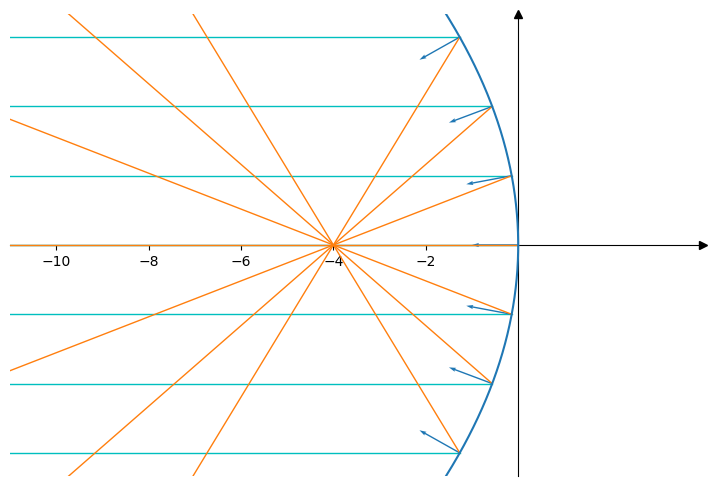

In [32]:
def _find_r_from_i_and_n(i, n):
    return i - 2 * np.dot(i, n) * n

def _find_reflection_rays_unit():
    rays = []
    for normal in normals:
        reflection_ray_unit = _find_r_from_i_and_n(incident_direction, normal)
        reflection_ray_unit = reflection_ray_unit / np.linalg.norm(reflection_ray_unit)
        rays.append(reflection_ray_unit)
    return np.array(rays, dtype=float)

reflection_rays_unit = _find_reflection_rays_unit()
# display(reflection_rays_unit)

def draw_reflection_rays():
    x_span = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_span = ax.get_ylim()[1] - ax.get_ylim()[0]
    reflection_ray_len = np.sqrt((2 * x_span)**2 + (2 * y_span)**2)

    for intersection_point, reflection_ray_unit in zip(intersection_points, reflection_rays_unit):
        end = intersection_point + reflection_ray_unit * reflection_ray_len
        ax.plot(
            [intersection_point[0], end[0]], [intersection_point[1], end[1]],
            color='C1', linewidth=1, zorder=4,
        )

fig, ax = plt.subplots(figsize=(10, 6))
set_scene()
draw_parabola()
draw_incident_rays()
draw_normals()
draw_reflection_rays()

## 总结

通过本次代码模拟，我们非常直观地验证了抛物线反射镜的核心光学特性，同时也证明了此前推导的向量反射公式在代码实现中的极简与精确。主要可以得出以下几点结论：

### 1. 完美的平行光聚焦
观察最终生成的图像可以清晰地看到，所有从左侧水平射入的平行光（方向向量为 $(1, 0)$），无论距离中心光轴的高度（$y$ 值）是多少，在经过抛物线面反射后，**全部精准地交汇于 $x$ 轴上的同一点**。没有任何一条光线发生偏离，这完美展现了抛物面镜消除“球面像差（Spherical Aberration）”、将平行光聚焦于一点的光学绝活。

### 2. 焦点位置的数学验证
在本次全局设置中，我们定义的抛物线参数为 $p = 8$。
根据解析几何，对于开口向左、顶点在原点的抛物线方程 $y^2 = -2px$，其理论焦点坐标位于 $(-p/2, 0)$。
代入 $p = 8$，理论焦点应为 $(-4, 0)$。观察图表坐标系，所有反射光线（橙色线）的交点恰好严格落在 $x = -4$ 的位置。代码的数值模拟结果与几何数学理论严丝合缝！

### 3. 光线追踪底层逻辑的闭环
本次实践成功串联了几何光学与计算机图形学（Ray Tracing）的底层逻辑：
* **隐函数求导找法线**：利用隐函数方程 $y^2 + 2px = 0$ 计算梯度（偏导数），非常优雅地求出了抛物线上任意交点的法向量 $\mathbf{n}$。
* **向量点乘约束**：通过 $\mathbf{n}\cdot\mathbf{i} < 0$ 的严密判断，确保了法向量始终迎着入射光的方向。
* **反射公式的应用**：直接套用纯粹的向量反射公式 $\mathbf{r} = \mathbf{i} - 2(\mathbf{i}\cdot\mathbf{n})\mathbf{n}$，跳过了繁琐的三角函数角度计算，一步到位得出反射光方向。
